# MECH 309: Assignment 5, Question 3

_Cagri Arslan_

March 16, 2025

*All work can be found on https://github.com/imported-canuck/MECH-309*

In [12]:
# Imports
import numpy as np
from matplotlib import pyplot as plt
from scipy import linalg

plt.style.use("bmh") # plotting style

# a)

To write out the $\mathbf{A}\mathbf{x}=\mathbf{b}$ interpolation problem for $n=5$, we first recognize that the problem is well-posed as the size of the $\textbf{x}$ vector is the same as the size of the $\textbf{b}$ vector: both of size $n$. This means the interpolant is unique, and $\textbf{A}$ is a square matrix of size $(n \text{ x } n)$. As we have five points, we use five basis functions resulting in a polynomial of order 4. We are given give data points $(x_i, y_i)$. 

When using monomials, basis functions are $\beta = \{1, x, x^2, x^3, x^4\}$. Hence $\mathbf{A}\mathbf{x}=\mathbf{b}$, for a monomial basis, is written as:

$$
\tag{1}
\textbf{A}=\begin{bmatrix}
1 & x_1 & x_1^2 & x_1^3 & x_1^4\\
1 & x_2 & x_2^2 & x_2^3 & x_2^4\\
1 & x_3 & x_3^2 & x_3^3 & x_3^4\\
1 & x_4 & x_4^2 & x_4^3 & x_4^4\\
1 & x_5 & x_5^2 &x_5^3 & x_5^4
\end{bmatrix}

\quad

\textbf{x}=\begin{bmatrix}
q_1 \\
q_2 \\
q_3 \\
q_4 \\
q_5
\end{bmatrix}

\quad

\textbf{b}=\begin{bmatrix}
y_1 \\
y_2 \\
y_3 \\
y_4 \\
y_5
\end{bmatrix}
$$

And so the interpolating function is:

$$
f(x) = q_1+q_2x+q_3x^2+q_4x^3+q_5x^4
$$

When using Newton polynomials, we construct them as:

$$
\pi_{j}(x) = \prod_{k=1}^{j-1}(x-x_k) \quad j = 1, ..., n \quad \text{with } \pi_{1}(x) = 1
$$

Therefore:

$$
\begin{aligned}
\pi_{1}(x_i) &= 1 \\
\pi_{2}(x_i) &= (x_i-x_1) \\
\pi_{3}(x_i) &= (x_i-x_1)(x_i-x_2) \\
\pi_{4}(x_i) &= (x_i-x_1)(x_i-x_2)(x_i-x_3) \\
\pi_{5}(x_i) &= (x_i-x_1)(x_i-x_2)(x_i-x_3)(x_i-x_4)
\end{aligned}
$$

Noting that $\pi_{j}(x_i) = 0 \; \forall i<j$, we can write out:

$$
\tag{2}
\textbf{A}=\begin{bmatrix}
1 & 0 & 0 & 0 & 0\\
1 & (x_2-x_1) & 0 & 0 & 0\\
1 & (x_3-x_1) & (x_3-x_1)(x_3-x_2) & 0 & 0\\
1 & (x_4-x_1) & (x_4-x_1)(x_4-x_2) & (x_4-x_1)(x_4-x_2)(x_4-x_3) & 0\\
1 & (x_5-x_1) & (x_5-x_1)(x_5-x_2) & (x_5-x_1)(x_5-x_2)(x_5-x_3) & (x_5-x_1)(x_5-x_2)(x_5-x_3)(x_5-x_4)
\end{bmatrix}

\quad

\textbf{x}=\begin{bmatrix}
q_1 \\
q_2 \\
q_3 \\
q_4 \\
q_5
\end{bmatrix}

\quad

\textbf{b}=\begin{bmatrix}
y_1 \\
y_2 \\
y_3 \\
y_4 \\
y_5
\end{bmatrix}
$$

And so the interpolating function is:

$$
f(x) = q_1 + q_2(x-x_1) + q_3(x-x_1)(x-x_2) + q_4(x-x_1)(x-x_2)(x-x_3) + q_5(x-x_1)(x-x_2)(x-x_3)(x-x_4)
$$

When using Lagrange polynomials as a basis, the basis functions follow the fundamental property that:

$$
L_j(x_i) = \delta_{ij}
$$

Therefore, trivially:

$$
\tag{3}
\textbf{A}=\begin{bmatrix}
1 & 0 & 0 & 0 & 0\\
0 & 1 & 0 & 0 & 0\\
0 & 0 & 1 & 0 & 0\\
0 & 0 & 0 & 1 & 0\\
0 & 0 & 0 & 0 & 1
\end{bmatrix}

\quad

\textbf{x}=\begin{bmatrix}
q_1 \\
q_2 \\
q_3 \\
q_4 \\
q_5
\end{bmatrix}

\quad

\textbf{b}=\begin{bmatrix}
y_1 \\
y_2 \\
y_3 \\
y_4 \\
y_5
\end{bmatrix}
$$

# b)

**Yes**. For all three matrices $\textbf{A}$ in (1) (2) and (3), $\textrm{rank}(A) = 5$. Since the five basis functions in each case are linearly independent and the five interpolation nodes $(x_1, ..., x_5)$ are distinct, the interpolation system must have a unique solution. Therefore $\textbf{A}$ is invertible. Since $\textbf{A}$ is square and invertible, it must be full rank, meaning $\textrm{rank}(A) = n = 5$. More rigorously:  

**Monomial Basis:** $\textbf{A}$ is a Vandermode matrix built from distinct $x_i$, so it is nonsingular. Hence rank 5.  
**Newton Basis:** $\textbf{A}$ is lower triangular, meaning $\textrm{det{(A)}}$ is the product of the main diagonal entries. Since these are all nonzero (as all $x_i$ are distinct),$\textrm{det{(A)}}$ is nonzero, meaning $\textbf{A}$ is nonsingular. Hence rank 5.  
**Lagrange Basis:** $\textbf{A}$ = $I_5$. The identity matrix is obviously invertible (it is its own inverse) and thus nonsingular. Hence rank 5. 

# c)

The structure of the matrix $\textbf{A}$ depends on the chosen basis:

**Monomial Basis:** $\textbf{A}$ is a full/dense Vandermode matrix, so there is no simple triangular structure to exploit. A general dense solver is appropriate, such as LU or QR, with cost on the order of $O(n^3)$  
**Newton Basis:** $\textbf{A}$ is lower triangular, so the system can be solved efficiently by forward substitution in $O(n^2)$    
**Lagrange Basis:** $\textbf{A}$ = $I_5$, so the coefficients are immediately $q_i=y_i$. There is no solve step beyond reading off the entries, which is $O(n)$.


# d)

We are given 5 $(x_i, y_i)$ points: $(-5, -4), (0, 2), (5, 4), (15, 1), (20, -1)$. Using the strucutres in (a), we can construct the corresponding $\textbf{A}$ matrices for each basis (Monomial, Newton, Lagrange) and the invariant $\textbf{b}$.  

*Note:* The hint suggests we create a function that computes the values of the basis functions. This is not yet necessary.

In [13]:
# Sample data

data = np.array([[-5, -4],
                [0, 2],
                [5, 4],
                [15, 1],
                [20, -1]], dtype='float')

First we create the universal $\textbf{b}$ vector. This is always the same, just a vector of y-values.

In [14]:
b = np.array([data[:, 1]]).T # target values (y) (n x 1)

**Monomial Basis:** We now create the $\textbf{A}$ (Vandermode) matrix for the canonical basis vectors. As computed below:

$$
\textbf{A}=\begin{bmatrix}
1.0000 & -5.0000 & 25.0000 & -125.0000 & 625.0000 \\
1.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 \\
1.0000 & 5.0000 & 25.0000 & 125.0000 & 625.0000 \\
1.0000 & 15.0000 & 225.0000 & 3375.0000 & 50625.0000 \\
1.0000 & 20.0000 & 400.0000 & 8000.0000 & 160000.0000
\end{bmatrix}
$$

In [15]:
def A_monomial(data, degree):
    """Constructs the design matrix A for monomial basis functions."""
    n = data.shape[0] # number of samples
    A = np.ones((n, degree + 1)) # initialize A with ones for the bias term
    for d in range(1, degree + 1):
        A[:, d] = data[:, 0] ** d # fill in the monomial terms
    return A

A_mon = A_monomial(data, 4)
print(A_mon)

[[ 1.0000e+00 -5.0000e+00  2.5000e+01 -1.2500e+02  6.2500e+02]
 [ 1.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
 [ 1.0000e+00  5.0000e+00  2.5000e+01  1.2500e+02  6.2500e+02]
 [ 1.0000e+00  1.5000e+01  2.2500e+02  3.3750e+03  5.0625e+04]
 [ 1.0000e+00  2.0000e+01  4.0000e+02  8.0000e+03  1.6000e+05]]


**Newton Basis:** We create the lower triangular $\textbf{A}$ matrix for Newton basis vectors. As computed below:

$$
\textbf{A}=\begin{bmatrix}
1.00 & 0.00 & 0.00 & 0.00 & 0.00 \\
1.00 & 5.00 & 0.00 & 0.00 & 0.00 \\
1.00 & 10.00 & 50.00 & 0.00 & 0.00 \\
1.00 & 20.00 & 300.00 & 3000.00 & 0.00 \\
1.00 & 25.00 & 500.00 & 7500.00 & 37500.00
\end{bmatrix}
$$

In [16]:
def A_newton(data, degree):
    """Constructs the design matrix A for Newton basis functions."""
    n = data.shape[0] # number of samples
    A = np.ones((n, degree + 1)) # initialize A with ones for the bias term
    for d in range(1, degree + 1):
        A[:, d] = np.prod([data[:, 0] - data[i, 0] for i in range(d)], axis=0) # fill in the Newton terms
    return A

A_newt = A_newton(data, 4)
print(A_newt)

[[ 1.00e+00  0.00e+00 -0.00e+00  0.00e+00 -0.00e+00]
 [ 1.00e+00  5.00e+00  0.00e+00 -0.00e+00  0.00e+00]
 [ 1.00e+00  1.00e+01  5.00e+01  0.00e+00 -0.00e+00]
 [ 1.00e+00  2.00e+01  3.00e+02  3.00e+03  0.00e+00]
 [ 1.00e+00  2.50e+01  5.00e+02  7.50e+03  3.75e+04]]


**Lagrange Basis:** The $\textbf{A}$ matrix for Lagrange basis vectors is simply the identity matrix:

In [17]:
A_lagrange = np.eye(data.shape[0]) # Lagrange basis is just the identity matrix for n samples

print(A_lagrange)

[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


# e)

We now compute the condition number of each $\textbf{A}$ matrix based on the induced 2-norm. 

**Monomial Basis:** We use ```np.linalg.cond``` to compute the condition number of $\textbf{A}$. As seen below, it is $\boxed{169,000}$. Classified as **bad**.

**Newton Basis:** We use ```np.linalg.cond``` to compute the condition number of $\textbf{A}$. As seen below, it is $\boxed{39,000}$. Classified as **okay**.

**Lagrange Basis** Computation is not necessary, the condition number of the identity matrix is $\boxed{1}$. It is perfectly conditioned. Classified as **good**. 

In [ ]:
# Condition numbers
cond_monomial = np.linalg.cond(A_mon)
cond_newton = np.linalg.cond(A_newt)

print(f"Condition number of A (monomial): {cond_monomial:.2e}")
print(f"Condition number of A (Newton): {cond_newton:.2e}")

Condition number of A (monomial): 1.69e+05
Condition number of A (Newton): 3.90e+04


# f)

We now numerically evaluate the $\textbf{x}$ coefficient vector for each basis. 

In [ ]:
# Solving for coefficients
x_mon = np.linalg.solve(A_mon, b)
x_newt = np.linalg.solve(A_newt, b)
x_lagrange = np.linalg.solve(A_lagrange, b)

print("Solved coefficient vectors:\n")
print(f"Monomial basis : {np.round(x_mon.flatten(), 6)}")
print(f"Newton basis   : {np.round(x_newt.flatten(), 6)}")
print(f"Lagrange basis : {np.round(x_lagrange.flatten(), 6)}")

Solved coefficient vectors:

Monomial basis : [ 2.00000e+00  7.63333e-01 -8.03330e-02  1.46700e-03  1.30000e-05]
Newton basis   : [-4.000e+00  1.200e+00 -8.000e-02  1.667e-03  1.300e-05]
Lagrange basis : [-4.  2.  4.  1. -1.]


As shown above:

$$
\begin{aligned}
\text{Monomial basis:}\quad \mathbf{x} &= 
\begin{bmatrix}
2.00000 \\
0.763333 \\
-0.0803330 \\
0.00146700 \\
0.0000130
\end{bmatrix}
\\[1em]
\text{Newton basis:}\quad \mathbf{x} &= 
\begin{bmatrix}
-4.000 \\
1.200 \\
-0.0800 \\
0.001667 \\
0.0000130
\end{bmatrix}
\\[1em]
\text{Lagrange basis:}\quad \mathbf{x} &= 
\begin{bmatrix}
-4 \\
2 \\
4 \\
1 \\
-1
\end{bmatrix}
\end{aligned}
$$

It should be noted that $\mathbf{x}$ vectors are **not** the same for different choices of basis. However, the interpolant function will end up being the same. 

# g)

To plot the interpolating polynomial, we reconstruct the polynomial from the coefficient vector obtained in part (f). The important point is that although the coefficient vectors differ between the monomial, Newton, and Lagrange bases, they all represent the **same interpolating polynomial**. Therefore, when plotted, all three forms should coincide.

For the monomial basis,
$$
\phi_1(x)=1,\qquad \phi_2(x)=x,\qquad \phi_3(x)=x^2,\qquad \phi_4(x)=x^3,\qquad \phi_5(x)=x^4.
$$
Hence the interpolating polynomial is
$$
p_{\text{mon}}(x)=q_1+q_2x+q_3x^2+q_4x^3+q_5x^4.
$$

For the Newton basis,
$$
\phi_1(x)=1,
$$
$$
\phi_2(x)=(x-x_1),
$$
$$
\phi_3(x)=(x-x_1)(x-x_2),
$$
$$
\phi_4(x)=(x-x_1)(x-x_2)(x-x_3),
$$
$$
\phi_5(x)=(x-x_1)(x-x_2)(x-x_3)(x-x_4).
$$
So the interpolating polynomial is
$$
p_{\text{Newt}}(x)=q_1+q_2(x-x_1)+q_3(x-x_1)(x-x_2)+q_4(x-x_1)(x-x_2)(x-x_3)+q_5(x-x_1)(x-x_2)(x-x_3)(x-x_4).
$$

For the Lagrange basis,
$$
L_j(x)=\prod_{\substack{m=1 \\ m\neq j}}^{5}\frac{x-x_m}{x_j-x_m}, \qquad j=1,\dots,5,
$$
and the interpolating polynomial is
$$
p_{\text{Lag}}(x)=\sum_{j=1}^{5} q_j L_j(x).
$$
Since the Lagrange interpolation matrix is the identity, the coefficient vector is simply
$$
\mathbf{q}=
\begin{bmatrix}
y_1 \\ y_2 \\ y_3 \\ y_4 \\ y_5
\end{bmatrix},
$$
so equivalently,
$$
p_{\text{Lag}}(x)=\sum_{j=1}^{5} y_j L_j(x).
$$

Thus, in part (g), we evaluate each form on a fine grid of $x$-values and plot them together with the original data points. Because all three bases define the same interpolant, the three curves should overlap exactly, up to small floating-point rounding differences.

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Extract interpolation nodes and data values from the given 5x2 array
x_nodes = data[:, 0]
y_nodes = data[:, 1]

# Coefficient vectors from part (f)
q_mon = x_mon.flatten()
q_newt = x_newt.flatten()
q_lagrange = x_lagrange.flatten()

print("x nodes:", x_nodes)
print("y nodes:", y_nodes)
print("Monomial coeffs :", np.round(q_mon, 6))
print("Newton coeffs   :", np.round(q_newt, 6))
print("Lagrange coeffs :", np.round(q_lagrange, 6))

x nodes: [-5.  0.  5. 15. 20.]
y nodes: [-4.  2.  4.  1. -1.]
Monomial coeffs : [ 2.00000e+00  7.63333e-01 -8.03330e-02  1.46700e-03  1.30000e-05]
Newton coeffs   : [-4.000e+00  1.200e+00 -8.000e-02  1.667e-03  1.300e-05]
Lagrange coeffs : [-4.  2.  4.  1. -1.]


In [ ]:
def eval_monomial(x, q):
    '''
    Evaluates the monomial basis polynomial at given x values using 
    coefficients q.

        Parameters:
        x : array-like
            The input x values where the polynomial is evaluated.
        q : array-like
            Coefficients of the monomial basis polynomial, where q[i] is the 
            coefficient for x^i.

        Returns:
        p : array-like
            The evaluated polynomial values at the input x.
    '''
    x = np.asarray(x, dtype=float) 
    return (
        q[0]
        + q[1] * x
        + q[2] * x**2
        + q[3] * x**3
        + q[4] * x**4
    )

def eval_newton(x, q, x_nodes):
    '''
    Evaluates the Newton basis polynomial at given x values using
    coefficients q and interpolation nodes x_nodes.
    
        Parameters:
        x : array-like
            The input x values where the polynomial is evaluated.
        q : array-like
            Coefficients of the Newton basis polynomial, where q[i] is the 
            coefficient for the i-th Newton basis function.
        x_nodes : array-like
            The interpolation nodes used to build the Newton basis functions.

        Returns:
        p : array-like
            The evaluated polynomial values at the input x.
    '''
    x = np.asarray(x, dtype=float)
    return (
        q[0]
        + q[1] * (x - x_nodes[0])
        + q[2] * (x - x_nodes[0]) * (x - x_nodes[1])
        + q[3] * (x - x_nodes[0]) * (x - x_nodes[1]) * (x - x_nodes[2])
        + q[4] * (x - x_nodes[0]) * (x - x_nodes[1]) * (x - x_nodes[2]) * (x - x_nodes[3])
    )

def lagrange_basis(x, j, x_nodes):
    ''' 
    Evaluates the j-th Lagrange basis function at given x values using
    interpolation nodes x_nodes.
    
        Parameters:
        x : array-like
            The input x values where the basis function is evaluated.
        j : int
            The index of the Lagrange basis function to evaluate.
        x_nodes : array-like
            The interpolation nodes used to build the Lagrange basis functions.
        
        Returns:
        Lj : array-like
            The evaluated j-th Lagrange basis function values at the input x.
    '''
    x = np.asarray(x, dtype=float) 
    Lj = np.ones_like(x, dtype=float)
    # Compute the j-th Lagrange basis function using the formula:
    for m in range(len(x_nodes)): 
        if m != j: # skip the j-th node
            Lj *= (x - x_nodes[m]) / (x_nodes[j] - x_nodes[m])
    return Lj

def eval_lagrange(x, q, x_nodes):
    '''
    Evaluates the Lagrange basis polynomial at given x values using
    coefficients q and interpolation nodes x_nodes.
    
        Parameters:
        x : array-like
            The input x values where the polynomial is evaluated.
        q : array-like
            Coefficients of the Lagrange basis polynomial, where q[j] is the 
            coefficient for the j-th Lagrange basis function.
        x_nodes : array-like
            The interpolation nodes used to build the Lagrange basis functions.

        Returns:
        p : array-like
            The evaluated polynomial values at the input x.
    '''
    x = np.asarray(x, dtype=float)
    p = np.zeros_like(x, dtype=float)
    for j in range(len(x_nodes)):
        p += q[j] * lagrange_basis(x, j, x_nodes)
    return p

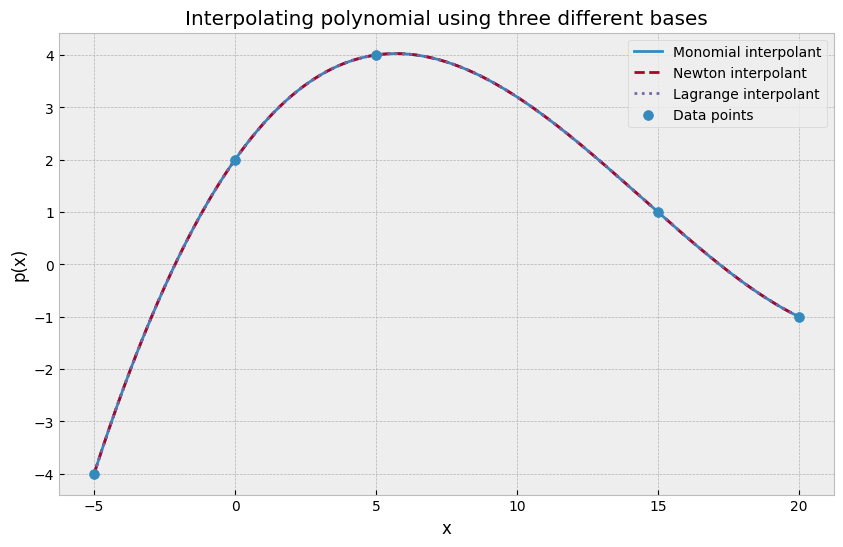

In [22]:
# Fine plotting grid
x_plot = np.linspace(np.min(x_nodes), np.max(x_nodes), 500)

# Evaluate each interpolant
y_mon = eval_monomial(x_plot, q_mon)
y_newt = eval_newton(x_plot, q_newt, x_nodes)
y_lagrange = eval_lagrange(x_plot, q_lagrange, x_nodes)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_mon, label="Monomial interpolant", linewidth=2)
plt.plot(x_plot, y_newt, "--", label="Newton interpolant", linewidth=2)
plt.plot(x_plot, y_lagrange, ":", label="Lagrange interpolant", linewidth=2)
plt.scatter(x_nodes, y_nodes, label="Data points", zorder=5, s=50)

plt.xlabel("x")
plt.ylabel("p(x)")
plt.title("Interpolating polynomial using three different bases")
plt.legend()
plt.grid(True)
plt.show()

As seen above, all three formulations produce the same interpolant function $p(x)$. This is because the interpolant is unique (as there are as many linearly independent basis functions as there are data points). We evaluate the maximum deviation between the pairwise interpolant curves. As shown below, all values are on the order of $10^{-15}$, indicating all three interpolant functions are indeed identical, differing only due to floating point errors.   

In [23]:
print("max |monomial - Newton|  =", np.max(np.abs(y_mon - y_newt)))
print("max |monomial - Lagrange| =", np.max(np.abs(y_mon - y_lagrange)))
print("max |Newton - Lagrange|   =", np.max(np.abs(y_newt - y_lagrange)))

max |monomial - Newton|  = 9.547918011776346e-15
max |monomial - Lagrange| = 7.438494264988549e-15
max |Newton - Lagrange|   = 6.6058269965196814e-15


The three plotted curves overlap, confirming that the monomial, Newton, and Lagrange formulations produce the same interpolating polynomial, even though their coefficient vectors are different because they are expressed in different bases.

## g.i) 
The Lagrange basis gives the smallest condition number because its interpolation matrix is the identity:
$$
A = I.
$$
Therefore,
$$
\kappa_2(A) = \kappa_2(I) = 1,
$$
which is the smallest possible condition number. This means the Lagrange formulation is perfectly conditioned.

From a numerical conditioning standpoint, the Lagrange basis is therefore the best choice. However, there is a tradeoff. Although the system is trivial to solve once the Lagrange basis is formed, the Lagrange basis functions themselves are more cumbersome to construct and evaluate, since each basis polynomial involves a product over all other nodes. By contrast, the Newton basis is also well-structured, but its basis functions are easier to build recursively, and its matrix is lower triangular, so the coefficients can be found efficiently using forward substitution. Thus, Lagrange offers the best conditioning, while Newton often offers a good balance between numerical stability and ease of computation. The monomial basis is generally the least desirable, since the associated Vandermonde matrix is dense and often poorly conditioned.

## g.ii) 

Yes, in exact arithmetic, the same interpolating plot should be obtained regardless of whether the monomial, Newton, or Lagrange basis is used. This is because all three choices are simply different bases for the same vector space of polynomials of degree at most $4$. Since there are five distinct data points, the interpolation problem has a unique polynomial solution of degree at most $4$. Therefore, although the coefficient vectors differ depending on the chosen basis, they all represent the same interpolating polynomial.

In practice, the computed plots may differ slightly due to floating-point roundoff errors, especially when using a poorly conditioned basis such as monomials. However, theoretically, the interpolated curve is identical for all three bases.